## Introdução

Praticando regressão linear com os laboratórios da especialização: Aprendizado de Máquina da `DeepLearning.AI`.  
Foram feitas anotações pessoais, os códigos foram reescritos e mais informações foram inseridas, com o objetivo de praticar os estudos e usar as informações aqui para futuras consultas.


In [14]:
# Importando bibliotecas 

import numpy as np
import matplotlib.pyplot as plt
from utils import * # usada para carregar os dados
import copy
import math
# Plotando os gráficos diretamente
%matplotlib inline  

## Descrição do problema

Identificar, em uma cadeia de restaurantes, qual é a mais lucrativa e quais são as potenciais filiais para serem abertas. Para isso, será usada a regressão linear com uma `feature` para realizar a previsão.  
Nosso dataset se encontra em `/data`, onde será usado o arquivo `ex1data1.txt`
- x_train: a população da cidade
- y_train: lucro do restaurante, valores negativos indicam prejuízo

Ambos os valores são numpy arrays (carregamos com numpy)

## Explorando os dados

Antes de aplicar a regressão linear é importante analisar os dados: verificar como eles são, qual é a sua grandeza em valores, se são inteiros ou decimais, qual é a quantidade de amostras que temos, qual é o shape do tensor e também, visualmente, como os dados estão distribuídos.  
Os valores representam o valor médio mensal, na escala de $10.000,00

Por exemplo  
9.1302 representa 91.302  
6.1101 representa 61.101

In [15]:
# Load dataset
x_train, y_train = load_data()

# Verificando se o dataset carregou com sucesso
print(f"Tipo de dados em x_train: {type(x_train)}")
print(f"Os 5 primeiros elementos de x_train: {x_train[:5]} \n")

print(f"Tipo de dados em y_train: {type(y_train)}")
print(f"Os 5 primeiros elementos: {y_train[:5]}")

Tipo de dados em x_train: <class 'numpy.ndarray'>
Os 5 primeiros elementos de x_train: [6.1101 5.5277 8.5186 7.0032 5.8598] 

Tipo de dados em y_train: <class 'numpy.ndarray'>
Os 5 primeiros elementos: [17.592   9.1302 13.662  11.854   6.8233]


Verificando o `shape`, ou seja, a quantidade de amostras que temos no dataset, vemos que se trata de um tensor de rank 1 (também conhecido como vetor), com 97 elementos ao longo do seu único eixo.

In [16]:
# Checando a dimensão dos numpy arrays

print(f"O shape de x_train: {x_train.shape}")
print(f"O shape de y_train: {y_train.shape}")
print(f"Número de exemplos de treino (m): {len(x_train)}")

O shape de x_train: (97,)
O shape de y_train: (97,)
Número de exemplos de treino (m): 97


Vamos cruzar os dados de treino — feature e alvo — para ver visualmente a distribuição dos dados.

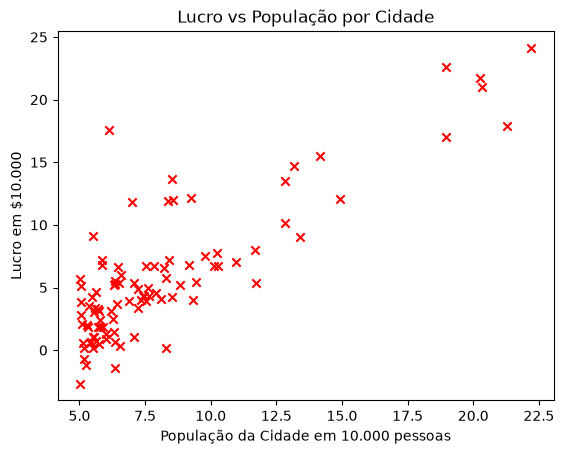

In [17]:
# Explorando os dados com scatter plot
# Definindo a cor e formato de marcação
plt.scatter(x_train, y_train, marker='x', c='r')

# Definição do título
plt.title("Lucro vs População por Cidade")
# Rótulo eixo Y
plt.ylabel("Lucro em $10.000")
# Rótulo no eixo X
plt.xlabel("População da Cidade em 10.000 pessoas")
plt.show()

## Objetivo do laboratório

Treinar um modelo de regressão linear. Após o treinamento, teremos um modelo capaz de prever o potencial de ganho mensal do restaurante.

`x` é a quantidade de população na função linear: **𝑓𝑤,𝑏(𝑥)=𝑤𝑥+𝑏**.  
Precisamos encontrar os melhores valores de `w` e `b`; para isso devemos utilizar a função de custo **𝐽(𝑤,𝑏)** e obter o menor valor possível.  
Para encontrar o menor custo devemos aplicar o método do **gradiente descendente**.

Vamos primeiro implementar a `função de custo`, depois desenvolveremos o `cálculo do gradiente` e, por fim, utilizaremos a função de `descida do gradiente` para encontrar o melhor peso (w) e bias (b), a fim de prever o lucro de um restaurante em função da população de uma cidade.

### 1. Função de custo

É com ela que sabemos, em média, o quão errado nosso modelo está; elevando ao quadrado, conseguimos penalizar ainda mais os erros maiores.
Como fazemos isso: calculamos a diferença entre a função linear (f_wb) e o alvo y[i], elevamos essa diferença ao quadrado e tiramos a média. Fórmula:

$$
J(w,b) = \frac{1}{2m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2
$$

In [18]:
# Ex 1
# Função de custo
# UNQ_C1

def compute_cost(x, y, w, b): 
    """
    Computes the cost function for linear regression.
    
    Args:
        x (ndarray): Shape (m,) Input to the model (Population of cities) 
        y (ndarray): Shape (m,) Label (Actual profits for the cities)
        w, b (scalar): Parameters of the model
    
    Returns
        total_cost (float): The cost of using w,b as the parameters for linear regression
               to fit the data points in x and y
    """
    # number of training examples
    m = x.shape[0]  #pegando a dimensão de linhas

    soma_custo = 0

    for i in range(m):
        f_wb = w * x[i] + b
        custo = (f_wb - y[i]) ** 2
        soma_custo = soma_custo + custo

    total_cost = (1 / (2 * m)) * soma_custo

    return total_cost

In [19]:
# Verificando se a função de custo foi implementada corretamente, passamos valores iniciais de w e b

w_inicial = 2
b_inicial = 1

custo = compute_cost(x_train, y_train, w_inicial, b_inicial)
print(type(custo))
print(f"Custo inicial de w: {custo:.3f}")


<class 'numpy.float64'>
Custo inicial de w: 75.203


### 2. Calculando o Gradiente

Para calcular o gradiente devemos obter a derivada em relação ao peso (w) e ao bias (b); os valores devem ser atualizados simultaneamente.

Fórmula:

$$
\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)}
$$

$$
\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})
$$

In [20]:
# Ex 2
# Gradiente descendente
# UNQ_C2

def compute_gradient(x, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      x (ndarray): Shape (m,) Input to the model (Population of cities) 
      y (ndarray): Shape (m,) Label (Actual profits for the cities)
      w, b (scalar): Parameters of the model  
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b     
     """
    
    # Number of training examples
    m = x.shape[0]
    
    # You need to return the following variables correctly
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = f_wb - y[i]
        dj_db += dj_db_i
        dj_dw += dj_dw_i

    dj_dw = dj_dw / m 
    dj_db = dj_db / m 
    
    return dj_dw, dj_db


In [21]:
# Verificando a função do gradiente descendente 

teste_w = 0.2
teste_b = 0.2

tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, teste_w, teste_b)
print(f"Gradiente nos testes w e b: {tmp_dj_dw, tmp_dj_db}")

Gradiente nos testes w e b: (np.float64(-47.41610118114435), np.float64(-4.007175051546391))


### 3. Função Gradiente Descendente

Agora que já temos implementadas a nossa função de custo — que será usada para registrar cada passo — e a função de cálculo do gradiente para w e b, podemos implementar a função de descida do gradiente. Nossa sequência é:

- Inicializar w e b (geralmente com 0, ou com valores pequenos aleatórios)

- Repetir até convergir:  
   a. Calcular a previsão f_wb(x) para todos os exemplos, usando o w e b atuais  
   b. Calcular o custo J(w,b) — só para monitorar/registrar (opcional a cada passo,   
      mas útil para plotar a curva de convergência)  
   c. Calcular o gradiente: ∂J/∂w e ∂J/∂b (usando o w e b atuais)  
   d. Atualizar simultaneamente:  
        w_novo = w - α * ∂J/∂w  
        b_novo = b - α * ∂J/∂b  
   e. w = w_novo, b = b_novo  

- Parar quando o custo parar de diminuir significativamente ou quando o número máximo de iterações for atingido

In [22]:
# Aprendendo parâmetros usando descida de gradiente em lote

def gradient_descent(x, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      x :    (ndarray): Shape (m,)
      y :    (ndarray): Shape (m,)
      w_in, b_in : (scalar) Initial values of parameters of the model
      cost_function: function to compute cost
      gradient_function: function to compute the gradient
      alpha : (float) Learning rate
      num_iters : (int) number of iterations to run gradient descent
    Returns
      w : (ndarray): Shape (1,) Updated values of parameters of the model after
          running gradient descent
      b : (scalar)                Updated value of parameter of the model after
          running gradient descent
    """
    
    # number of training examples
    m = len(x)
    
    # An array to store cost J and w's at each iteration — primarily for graphing later
    J_history = []
    w_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_dw, dj_db = gradient_function(x, y, w, b )  

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            cost =  cost_function(x, y, w, b)
            J_history.append(cost)

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            w_history.append(w)
            print(f"Iteração {i:4}: Custo {float(J_history[-1]):8.2f}   ")
        
    return w, b, J_history, w_history #return w and J,w history for graphing

In [23]:
# initialize fitting parameters. Recall that the shape of w is (n,)
initial_w = 0.
initial_b = 0.

# some gradient descent settings
iterations = 1500
alpha = 0.01

w,b,_,_ = gradient_descent(x_train ,y_train, initial_w, initial_b, 
                     compute_cost, compute_gradient, alpha, iterations)
print("w,b found by gradient descent:", w, b)

Iteração    0: Custo     6.74   
Iteração  150: Custo     5.31   
Iteração  300: Custo     4.96   
Iteração  450: Custo     4.76   
Iteração  600: Custo     4.64   
Iteração  750: Custo     4.57   
Iteração  900: Custo     4.53   
Iteração 1050: Custo     4.51   
Iteração 1200: Custo     4.50   
Iteração 1350: Custo     4.49   
w,b found by gradient descent: 1.166362350335582 -3.63029143940436


In [24]:
m = x_train.shape[0]
predicted = np.zeros(m)

for i in range(m):
    predicted[i] = w * x_train[i] + b

Text(0.5, 0, 'Population of City in 10,000s')

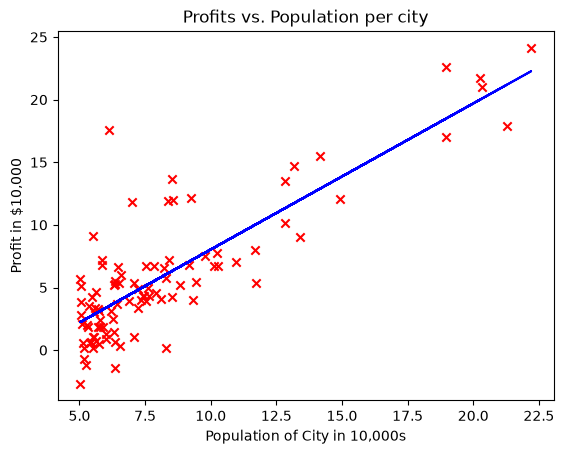

In [25]:
# Plot the linear fit
plt.plot(x_train, predicted, c = "b")

# Create a scatter plot of the data. 
plt.scatter(x_train, y_train, marker='x', c='r') 

# Set the title
plt.title("Profits vs. Population per city")
# Set the y-axis label
plt.ylabel('Profit in $10,000')
# Set the x-axis label
plt.xlabel('Population of City in 10,000s')

In [26]:
predict1 = 3.5 * w + b
print('For population = 35,000, we predict a profit of $%.2f' % (predict1*10000))

predict2 = 7.0 * w + b
print('For population = 70,000, we predict a profit of $%.2f' % (predict2*10000))

For population = 35,000, we predict a profit of $4519.77
For population = 70,000, we predict a profit of $45342.45


## Conclusão

Iniciamos `w` e `b` com valores (geralmente zero). A cada iteração, calculamos a função de custo `J(w,b)` usando os valores atuais de `w` e `b`, para sabermos o quão errado o modelo está.   
Em paralelo, calculamos o gradiente (as derivadas parciais `∂J/∂w` e `∂J/∂b`), que indicam a direção de maior crescimento do custo. Usamos esse gradiente para atualizar `w` e `b` (não o custo em si) — dando um passo na direção oposta ao gradiente, de tamanho proporcional a `α`. Repetimos esse processo (gradiente descendente); a cada iteração o valor do custo tende a diminuir, como consequência de `w` e `b` terem sido ajustados, até convergir num mínimo.